###Mount Google Drive

In [1]:
import shutil
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Load all six model comparison outputs

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)

FINAL_ROOT = "/content/drive/MyDrive/gnn_project/final_thesis_model_comparison"
COMBINED_PLOT_DIR = os.path.join(FINAL_ROOT, "combined_plots")
os.makedirs(COMBINED_PLOT_DIR, exist_ok=True)

MODEL_ORDER = [
    "baseline_gatv2",
    "baseline_graphsage",
    "spectral_gated_gatv2",
    "spectral_gated_graphsage",
    "baseline_dynamicedgeconv",
    "spectral_gated_dynamicedgeconv",
]

MODEL_DISPLAY = {
    "spectral_gated_graphsage": "Spectral-Gated GraphSAGE",
    "baseline_graphsage": "baseline_graphsage",
    "baseline_gatv2": "Baseline GATv2",
    "spectral_gated_gatv2": "Spectral-Gated GATv2",
    "baseline_dynamicedgeconv": "Baseline Dynamic EdgeConv",
    "spectral_gated_dynamicedgeconv": "Spectral-Gated Dynamic EdgeConv",
}

MODEL_SHORT = {
    "baseline_graphsage": "Base SAGE",
    "spectral_gated_graphsage": "SG SAGE",
    "baseline_gatv2": "Base GATv2",
    "spectral_gated_gatv2": "SG GATv2",
    "baseline_dynamicedgeconv": "Base DynEdge",
    "spectral_gated_dynamicedgeconv": "SG DynEdge",
}


def require_one(pattern, description):
    matches = sorted(glob.glob(pattern))
    if len(matches) == 0:
        raise FileNotFoundError(f"Missing {description}. Pattern:\n{pattern}")
    return matches[0]


cluster_dfs = {}
metrics_dfs = {}
mean_dfs = {}
std_dfs = {}

for model_key in MODEL_ORDER:
    model_dir = os.path.join(FINAL_ROOT, model_key)

    cluster_path = require_one(
        os.path.join(model_dir, f"{model_key}_ALL_SEEDS_test_cluster_predictions.csv"),
        f"cluster predictions for {model_key}",
    )

    metrics_path = require_one(
        os.path.join(model_dir, f"{model_key}_metrics_by_seed_threshold.csv"),
        f"metrics by seed/threshold for {model_key}",
    )

    mean_path = require_one(
        os.path.join(model_dir, f"{model_key}_metrics_MEAN_by_threshold.csv"),
        f"mean metrics for {model_key}",
    )

    std_path = require_one(
        os.path.join(model_dir, f"{model_key}_metrics_STD_by_threshold.csv"),
        f"std metrics for {model_key}",
    )

    cluster_dfs[model_key] = pd.read_csv(cluster_path)
    metrics_dfs[model_key] = pd.read_csv(metrics_path)
    mean_dfs[model_key] = pd.read_csv(mean_path)
    std_dfs[model_key] = pd.read_csv(std_path)

    print(f"Loaded {model_key}")
    print("  cluster:", cluster_dfs[model_key].shape)
    print("  metrics:", metrics_dfs[model_key].shape)
    print("  mean:", mean_dfs[model_key].shape)
    print("  std:", std_dfs[model_key].shape)

print("\nAll six models loaded successfully.")
print("Combined plot dir:", COMBINED_PLOT_DIR)

Loaded baseline_gatv2
  cluster: (109029, 16)
  metrics: (9, 57)
  mean: (3, 41)
  std: (3, 41)
Loaded baseline_graphsage
  cluster: (109029, 16)
  metrics: (9, 55)
  mean: (3, 41)
  std: (3, 41)
Loaded spectral_gated_gatv2
  cluster: (109029, 16)
  metrics: (9, 60)
  mean: (3, 48)
  std: (3, 48)
Loaded spectral_gated_graphsage
  cluster: (109029, 16)
  metrics: (9, 60)
  mean: (3, 48)
  std: (3, 48)
Loaded baseline_dynamicedgeconv
  cluster: (109029, 16)
  metrics: (9, 54)
  mean: (3, 42)
  std: (3, 42)
Loaded spectral_gated_dynamicedgeconv
  cluster: (109029, 16)
  metrics: (9, 60)
  mean: (3, 48)
  std: (3, 48)

All six models loaded successfully.
Combined plot dir: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots


###Combined ROC and Precision-Recall curves

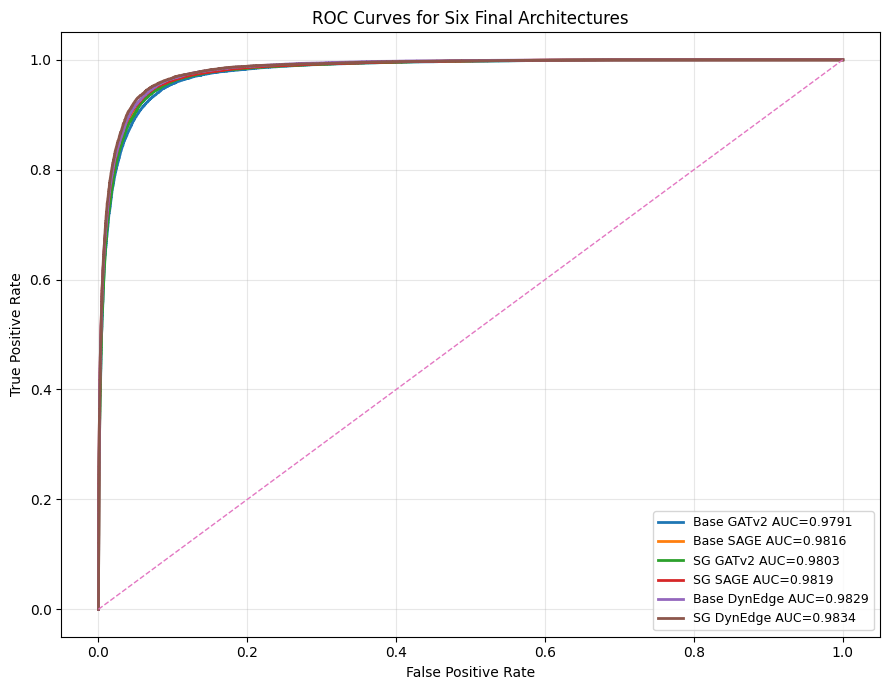

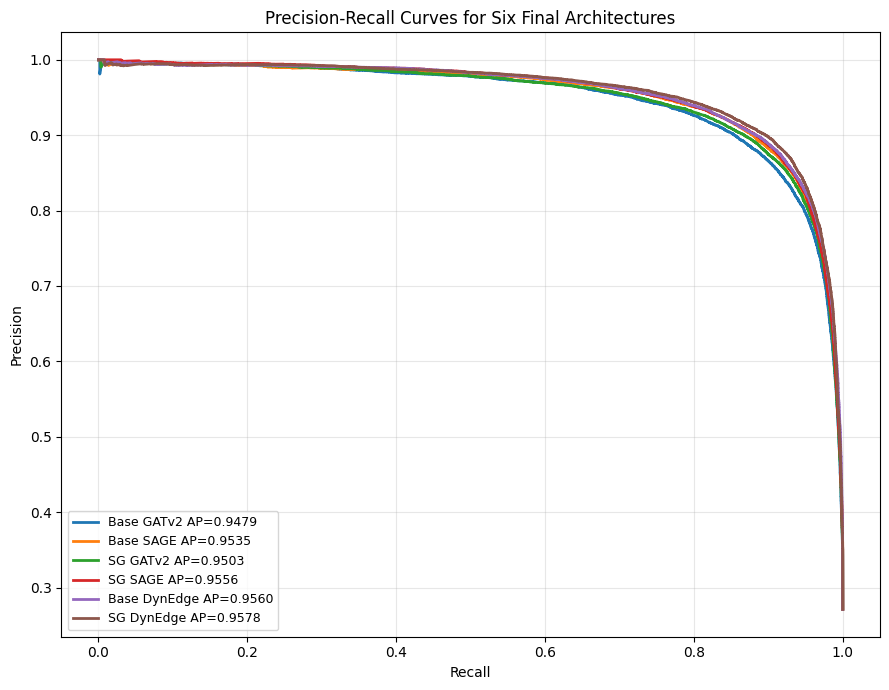

Saved:
/content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_six_model_roc_curves.png
/content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_six_model_precision_recall_curves.png
/content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_six_model_curve_summary.csv


,model_key,model,roc_auc_pooled,pr_auc_pooled,n_candidates,positive_rate
0,baseline_gatv2,Baseline GATv2,0.979119,0.947928,109029,0.271221
1,baseline_graphsage,baseline_graphsage,0.981632,0.953470,109029,0.271221
2,spectral_gated_gatv2,Spectral-Gated GATv2,0.980327,0.950316,109029,0.271221
3,spectral_gated_graphsage,Spectral-Gated GraphSAGE,0.981941,0.955569,109029,0.271221
4,baseline_dynamicedgeconv,Baseline Dynamic EdgeConv,0.982906,0.956041,109029,0.271221
5,spectral_gated_dynamicedgeconv,Spectral-Gated Dynamic EdgeConv,0.983395,0.957762,109029,0.271221


In [5]:

curve_rows = []
# ROC curves
plt.figure(figsize=(9, 7))

for model_key in MODEL_ORDER:
    df = cluster_dfs[model_key].copy()

    y_true = df["true_y"].astype(int).to_numpy()
    y_score = df["score"].astype(float).to_numpy()

    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    fpr, tpr, _ = roc_curve(y_true, y_score)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{MODEL_SHORT[model_key]} AUC={roc_auc:.4f}",
    )

    curve_rows.append({
        "model_key": model_key,
        "model": MODEL_DISPLAY[model_key],
        "roc_auc_pooled": roc_auc,
        "pr_auc_pooled": pr_auc,
        "n_candidates": len(df),
        "positive_rate": float(y_true.mean()),
    })

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Six Final Architectures")
plt.legend(fontsize=9, loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

roc_out = os.path.join(COMBINED_PLOT_DIR, "combined_six_model_roc_curves.png")
plt.savefig(roc_out, dpi=300, bbox_inches="tight")
plt.show()
# Precision-Recall curves
plt.figure(figsize=(9, 7))

for model_key in MODEL_ORDER:
    df = cluster_dfs[model_key].copy()

    y_true = df["true_y"].astype(int).to_numpy()
    y_score = df["score"].astype(float).to_numpy()

    pr_auc = average_precision_score(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{MODEL_SHORT[model_key]} AP={pr_auc:.4f}",
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Six Final Architectures")
plt.legend(fontsize=9, loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

pr_out = os.path.join(COMBINED_PLOT_DIR, "combined_six_model_precision_recall_curves.png")
plt.savefig(pr_out, dpi=300, bbox_inches="tight")
plt.show()

curve_summary_df = pd.DataFrame(curve_rows)
curve_summary_csv = os.path.join(COMBINED_PLOT_DIR, "combined_six_model_curve_summary.csv")
curve_summary_df.to_csv(curve_summary_csv, index=False)

print("Saved:")
print(roc_out)
print(pr_out)
print(curve_summary_csv)

display(curve_summary_df)

###Final six-model comparison table at threshold 0.7

In [6]:

FINAL_THRESHOLD = 0.7

rows = []

for model_key in MODEL_ORDER:
    mean_df = mean_dfs[model_key].copy()
    std_df = std_dfs[model_key].copy()

    mean_row = mean_df.iloc[(mean_df["threshold"] - FINAL_THRESHOLD).abs().argsort()[:1]].iloc[0]
    std_row = std_df.iloc[(std_df["threshold"] - FINAL_THRESHOLD).abs().argsort()[:1]].iloc[0]

    row = {
        "model_key": model_key,
        "model": MODEL_DISPLAY[model_key],
        "threshold": float(mean_row["threshold"]),
    }

    wanted = [
        "roc_auc",
        "pr_auc",
        "graph_f1",
        "event_purity",
        "event_efficiency",
        "event_fake_fraction",
        "duplicate_fraction",
        "duplicate_fraction_proxy",
        "selection_score",
        "energy_all_signal_mae",
        "energy_all_signal_rmse",
        "energy_all_signal_bias",
        "energy_all_signal_rel_mae",
        "energy_selected_signal_mae",
        "energy_selected_signal_rmse",
        "energy_selected_signal_bias",
        "energy_selected_signal_rel_mae",
    ]

    for col in wanted:
        if col in mean_row.index:
            row[f"{col}_mean"] = mean_row[col]
        if col in std_row.index:
            row[f"{col}_std"] = std_row[col]

    rows.append(row)

final_compare_df = pd.DataFrame(rows)

final_compare_csv = os.path.join(
    COMBINED_PLOT_DIR,
    f"final_six_model_comparison_threshold_{FINAL_THRESHOLD}.csv",
)

final_compare_df.to_csv(final_compare_csv, index=False)

print("Saved:", final_compare_csv)
display(final_compare_df)

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/final_six_model_comparison_threshold_0.7.csv


,model_key,model,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,graph_f1_mean,graph_f1_std,event_purity_mean,...,energy_selected_signal_mae_mean,energy_selected_signal_mae_std,energy_selected_signal_rmse_mean,energy_selected_signal_rmse_std,energy_selected_signal_bias_mean,energy_selected_signal_bias_std,energy_selected_signal_rel_mae_mean,energy_selected_signal_rel_mae_std,duplicate_fraction_proxy_mean,duplicate_fraction_proxy_std
0,baseline_gatv2,Baseline GATv2,0.7,0.979274,0.000936,0.948119,0.002804,0.881797,0.003428,0.879517,...,0.166334,0.012763,0.286342,0.015052,-0.023362,0.044060,0.079564,0.005546,NaN,NaN
1,baseline_graphsage,baseline_graphsage,0.7,0.981736,0.000463,0.953707,0.001207,0.891074,0.001181,0.883473,...,0.168419,0.014926,0.294654,0.011089,0.052334,0.054017,0.081971,0.006707,NaN,NaN
2,spectral_gated_gatv2,Spectral-Gated GATv2,0.7,0.980426,0.000251,0.950764,0.000455,0.887226,0.001868,0.875694,...,0.192067,0.034631,0.308902,0.029278,-0.108442,0.058179,0.092104,0.016325,NaN,NaN
3,spectral_gated_graphsage,Spectral-Gated GraphSAGE,0.7,0.982000,0.000650,0.955603,0.002238,0.893623,0.001395,0.884862,...,0.159246,0.005567,0.285111,0.006552,0.015846,0.033277,0.078690,0.002476,NaN,NaN
4,baseline_dynamicedgeconv,Baseline Dynamic EdgeConv,0.7,0.983018,0.000427,0.956226,0.001344,0.895061,0.003154,0.878847,...,0.157746,0.013843,0.274101,0.019696,0.015896,0.066670,0.079533,0.008232,0.0,0.0
5,spectral_gated_dynamicedgeconv,Spectral-Gated Dynamic EdgeConv,0.7,0.983714,0.000390,0.958666,0.000241,0.899043,0.001931,0.885166,...,0.136517,0.004035,0.254381,0.006775,0.015333,0.021609,0.069912,0.002336,NaN,NaN


###Selection score comparison

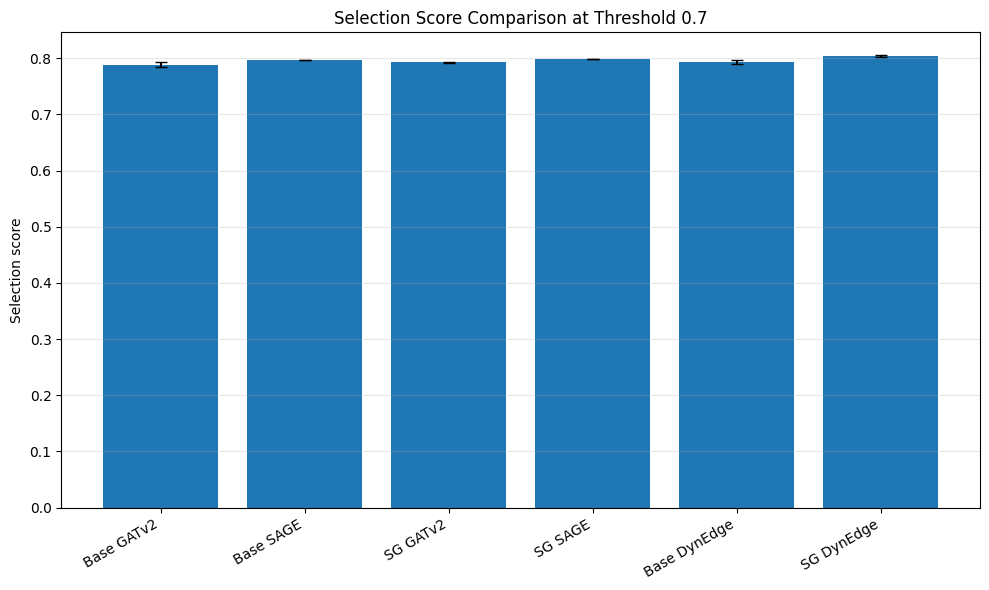

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_selection_score_bar_chart.png


In [18]:

plot_df = final_compare_df.copy()
plot_df["model_short"] = plot_df["model_key"].map(MODEL_SHORT)

x = np.arange(len(plot_df))
y = plot_df["selection_score_mean"].astype(float).to_numpy()

if "selection_score_std" in plot_df.columns:
    yerr = plot_df["selection_score_std"].astype(float).to_numpy()
else:
    yerr = None

plt.figure(figsize=(10, 6))
plt.bar(x, y, yerr=yerr, capsize=4)
plt.xticks(x, plot_df["model_short"], rotation=30, ha="right")
plt.ylabel("Selection score")
plt.title(f"Selection Score Comparison at Threshold {FINAL_THRESHOLD}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = os.path.join(COMBINED_PLOT_DIR, "combined_selection_score_bar_chart.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)

###Event metric grouped bar chart

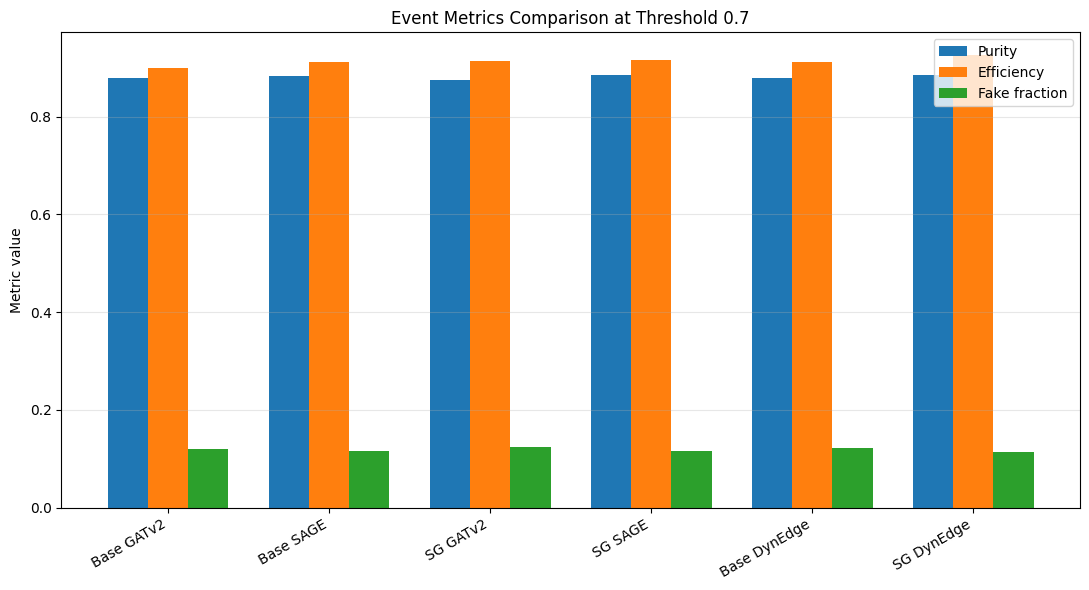

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_event_purity_efficiency_fake_fraction.png


In [19]:

plot_df = final_compare_df.copy()
plot_df["model_short"] = plot_df["model_key"].map(MODEL_SHORT)

metrics_to_plot = [
    ("event_purity_mean", "Purity"),
    ("event_efficiency_mean", "Efficiency"),
    ("event_fake_fraction_mean", "Fake fraction"),
]

available = [(c, label) for c, label in metrics_to_plot if c in plot_df.columns]

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(11, 6))

for i, (col, label) in enumerate(available):
    offset = (i - (len(available) - 1) / 2) * width
    plt.bar(x + offset, plot_df[col].astype(float), width=width, label=label)

plt.xticks(x, plot_df["model_short"], rotation=30, ha="right")
plt.ylabel("Metric value")
plt.title(f"Event Metrics Comparison at Threshold {FINAL_THRESHOLD}")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = os.path.join(COMBINED_PLOT_DIR, "combined_event_purity_efficiency_fake_fraction.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)

### Paired baseline vs spectral-gated comparison by backbone

,backbone,metric,baseline,spectral_gated,delta_spectral_minus_baseline
0,GraphSAGE,selection_score,0.796640,0.798685,0.002046
1,GraphSAGE,event_purity,0.883473,0.884862,0.001389
2,GraphSAGE,event_efficiency,0.912732,0.915580,0.002848
3,GraphSAGE,event_fake_fraction,0.116527,0.115138,-0.001389
4,GraphSAGE,graph_f1,0.891074,0.893623,0.002549
5,GraphSAGE,pr_auc,0.953707,0.955603,0.001896
6,GraphSAGE,roc_auc,0.981736,0.982000,0.000263
7,GATv2,selection_score,0.788483,0.792723,0.004240
8,GATv2,event_purity,0.879517,0.875694,-0.003823
9,GATv2,event_efficiency,0.899441,0.913536,0.014094


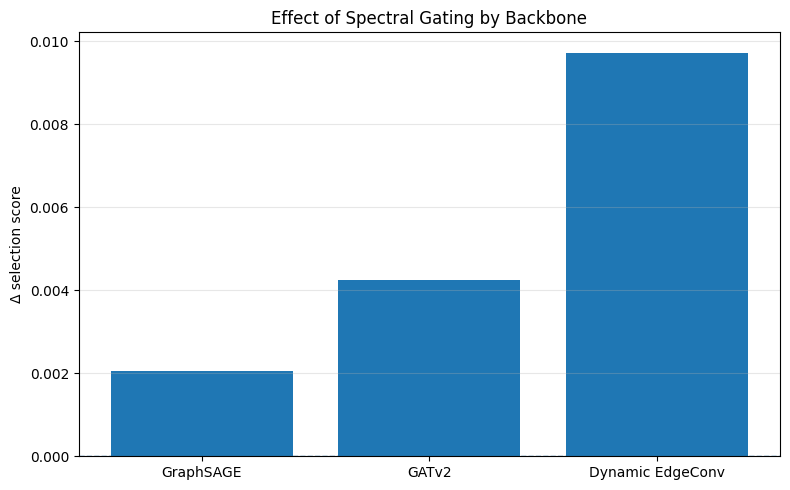

Saved:
/content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/paired_baseline_vs_spectral_gated_deltas.csv
/content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_spectral_gating_selection_score_delta.png


In [7]:


pairs = [
    ("GraphSAGE", "baseline_graphsage", "spectral_gated_graphsage"),
    ("GATv2", "baseline_gatv2", "spectral_gated_gatv2"),
    ("Dynamic EdgeConv", "baseline_dynamicedgeconv", "spectral_gated_dynamicedgeconv"),
]

paired_rows = []

for backbone, base_key, sg_key in pairs:
    base_matches = final_compare_df[final_compare_df["model_key"] == base_key]
    sg_matches = final_compare_df[final_compare_df["model_key"] == sg_key]

    if base_matches.empty or sg_matches.empty:
        print(f"Skipping {backbone} because baseline or spectral-gated variant is missing.")
        continue

    base = base_matches.iloc[0]
    sg = sg_matches.iloc[0]

    for metric in [
        "selection_score_mean",
        "event_purity_mean",
        "event_efficiency_mean",
        "event_fake_fraction_mean",
        "graph_f1_mean",
        "pr_auc_mean",
        "roc_auc_mean",
    ]:
        if metric in final_compare_df.columns:
            paired_rows.append({
                "backbone": backbone,
                "metric": metric.replace("_mean", ""),
                "baseline": float(base[metric]),
                "spectral_gated": float(sg[metric]),
                "delta_spectral_minus_baseline": float(sg[metric] - base[metric]),
            })

if paired_rows:
    paired_df = pd.DataFrame(paired_rows)

    paired_csv = os.path.join(COMBINED_PLOT_DIR, "paired_baseline_vs_spectral_gated_deltas.csv")
    paired_df.to_csv(paired_csv, index=False)

    display(paired_df)

    # Plot only key deltas.
    delta_metric = "selection_score"

    delta_plot_df = paired_df[paired_df["metric"] == delta_metric].copy()

    plt.figure(figsize=(8, 5))
    plt.bar(delta_plot_df["backbone"], delta_plot_df["delta_spectral_minus_baseline"])
    plt.axhline(0, linewidth=1, linestyle="--")
    plt.ylabel("Δ selection score")
    plt.title("Effect of Spectral Gating by Backbone")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    out = os.path.join(COMBINED_PLOT_DIR, "combined_spectral_gating_selection_score_delta.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(paired_csv)
    print(out)
else:
    print("No paired comparisons available to plot.")

###Combined energy-regression comparison plots

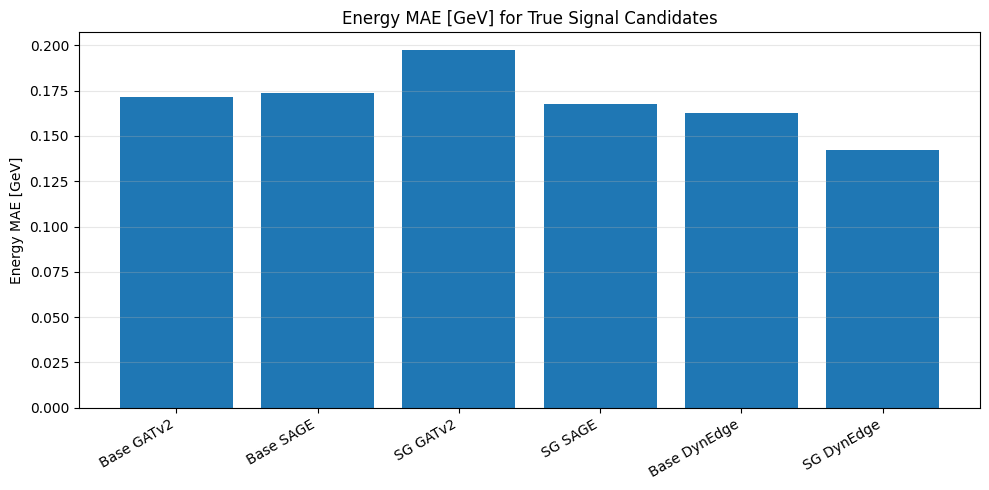

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_energy_mae_six_models.png


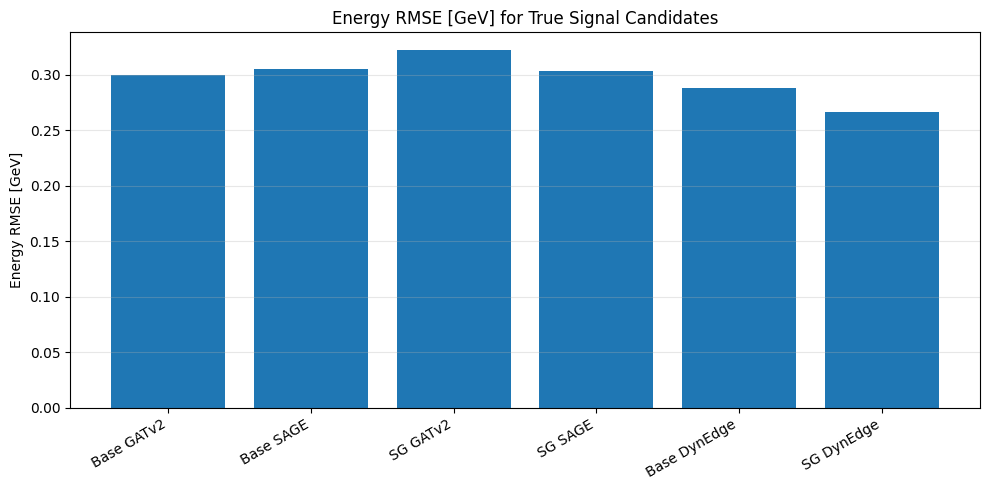

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_energy_rmse_six_models.png


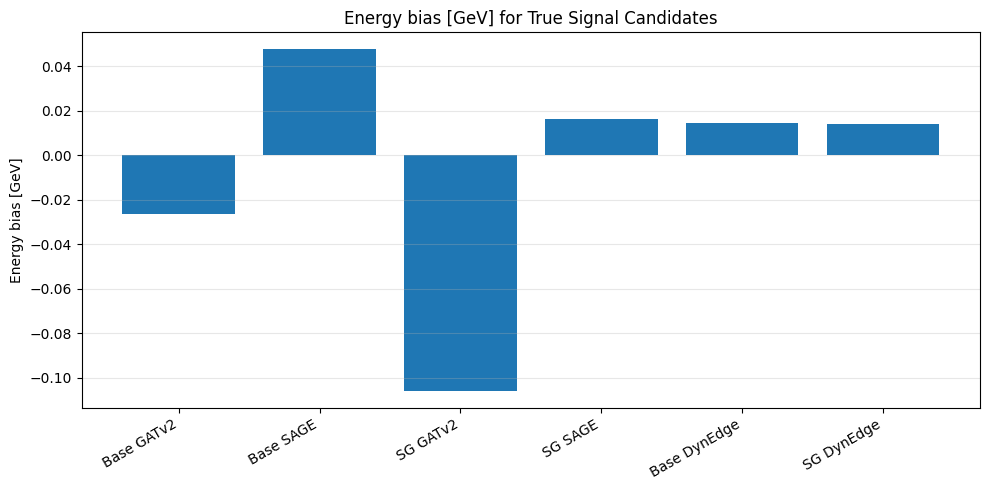

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_energy_bias_six_models.png


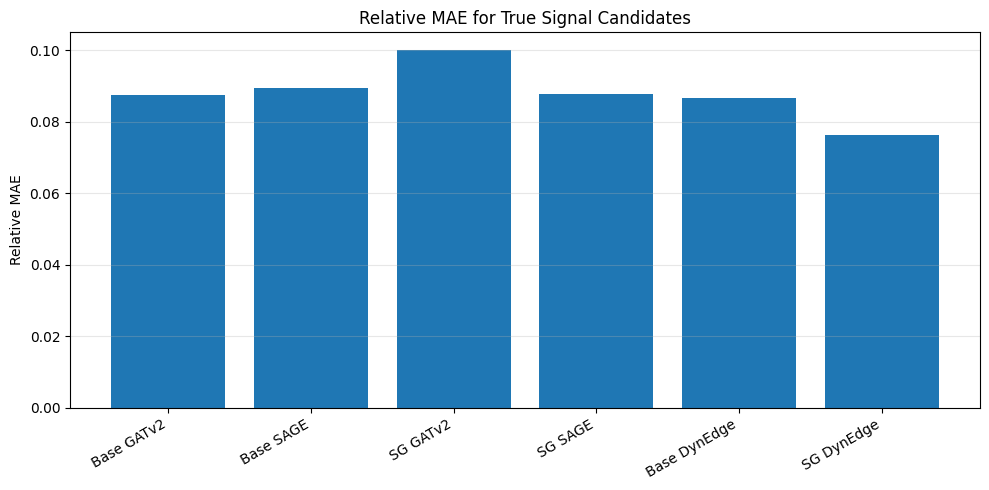

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_energy_relative_mae_six_models.png


In [8]:

import os
import numpy as np
import matplotlib.pyplot as plt

plot_df = final_compare_df.copy()
plot_df["model_short"] = plot_df["model_key"].map(MODEL_SHORT)

energy_metrics = [
    ("energy_all_signal_mae_mean", "Energy MAE [GeV]", "combined_energy_mae_six_models.png"),
    ("energy_all_signal_rmse_mean", "Energy RMSE [GeV]", "combined_energy_rmse_six_models.png"),
    ("energy_all_signal_bias_mean", "Energy bias [GeV]", "combined_energy_bias_six_models.png"),
    ("energy_all_signal_rel_mae_mean", "Relative MAE", "combined_energy_relative_mae_six_models.png"),
]

for col, ylabel, filename in energy_metrics:
    if col not in plot_df.columns:
        print(f"Skipping missing regression metric: {col}")
        continue

    values = plot_df[col].astype(float).to_numpy()
    x = np.arange(len(plot_df))

    plt.figure(figsize=(10, 5))
    plt.bar(x, values)
    plt.xticks(x, plot_df["model_short"], rotation=30, ha="right")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} for True Signal Candidates")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    out = os.path.join(COMBINED_PLOT_DIR, filename)
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out)

###Grouped regression plot: MAE, RMSE, Bias

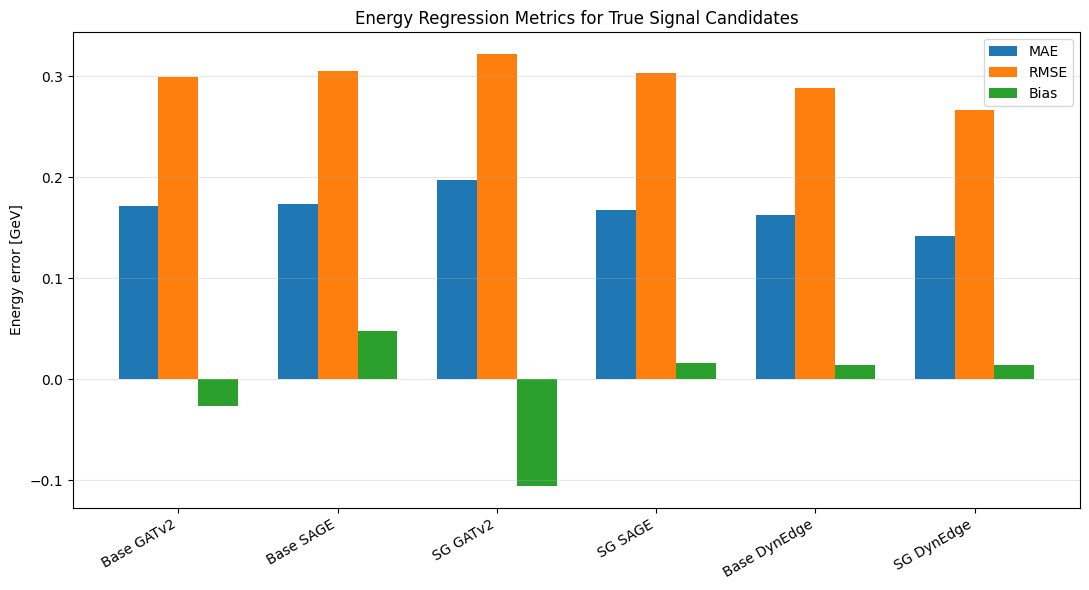

Saved: /content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/combined_energy_regression_grouped_mae_rmse_bias.png


In [9]:


reg_cols = [
    ("energy_all_signal_mae_mean", "MAE"),
    ("energy_all_signal_rmse_mean", "RMSE"),
    ("energy_all_signal_bias_mean", "Bias"),
]

available = [(c, label) for c, label in reg_cols if c in final_compare_df.columns]

if len(available) == 0:
    raise RuntimeError("No regression columns found in final_compare_df.")

plot_df = final_compare_df.copy()
plot_df["model_short"] = plot_df["model_key"].map(MODEL_SHORT)

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(11, 6))

for i, (col, label) in enumerate(available):
    offset = (i - (len(available) - 1) / 2) * width
    plt.bar(
        x + offset,
        plot_df[col].astype(float),
        width=width,
        label=label,
    )

plt.xticks(x, plot_df["model_short"], rotation=30, ha="right")
plt.ylabel("Energy error [GeV]")
plt.title("Energy Regression Metrics for True Signal Candidates")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = os.path.join(COMBINED_PLOT_DIR, "combined_energy_regression_grouped_mae_rmse_bias.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)

###Predicted vs true energy plot for best model

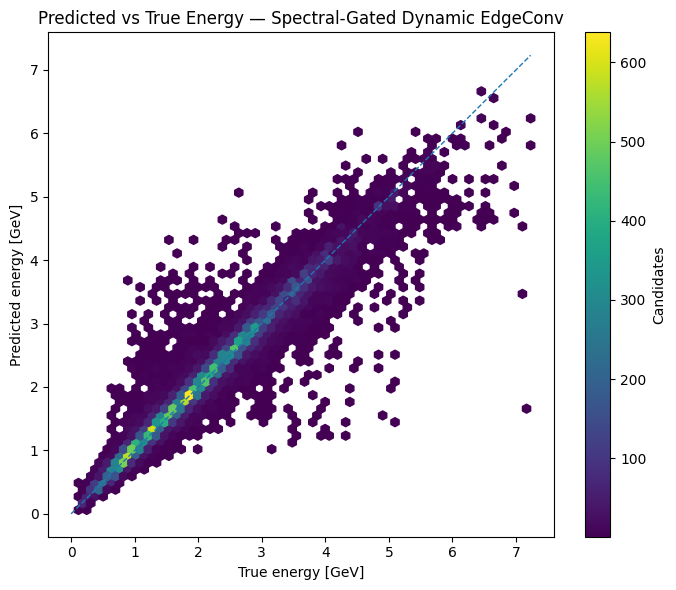

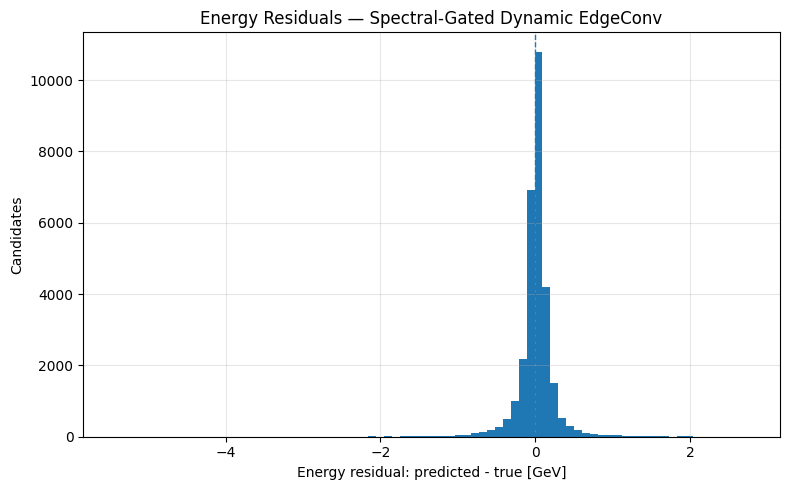

Saved:
/content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/best_model_energy_pred_vs_true_hexbin.png
/content/drive/MyDrive/gnn_project/final_thesis_model_comparison/combined_plots/best_model_energy_residual_histogram.png


In [ ]:


BEST_MODEL_KEY = "spectral_gated_dynamicedgeconv"

if BEST_MODEL_KEY not in cluster_dfs:
    raise RuntimeError(f"{BEST_MODEL_KEY} not found in cluster_dfs. Loaded models: {list(cluster_dfs.keys())}")

df = cluster_dfs[BEST_MODEL_KEY].copy()

pos = df[
    (df["true_y"].astype(int) > 0)
    & (df["true_E"].astype(float) > 0.1)
].copy()

if len(pos) == 0:
    raise RuntimeError("No positive signal candidates with true_E > 0.1 found.")

x = pos["true_E"].astype(float).to_numpy()
y = pos["pred_E"].astype(float).to_numpy()
err = y - x

# Predicted vs true energy
plt.figure(figsize=(7, 6))
plt.hexbin(x, y, gridsize=55, mincnt=1)
lim = max(float(np.nanmax(x)), float(np.nanmax(y)), 1.0)
plt.plot([0, lim], [0, lim], linestyle="--", linewidth=1)
plt.xlabel("True energy [GeV]")
plt.ylabel("Predicted energy [GeV]")
plt.title("Predicted vs True Energy — Spectral-Gated Dynamic EdgeConv")
plt.colorbar(label="Candidates")
plt.tight_layout()

out1 = os.path.join(COMBINED_PLOT_DIR, "best_model_energy_pred_vs_true_hexbin.png")
plt.savefig(out1, dpi=300, bbox_inches="tight")
plt.show()

# Residual histogram

plt.figure(figsize=(8, 5))
plt.hist(err, bins=80)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Energy residual: predicted - true [GeV]")
plt.ylabel("Candidates")
plt.title("Energy Residuals — Spectral-Gated Dynamic EdgeConv")
plt.grid(True, alpha=0.3)
plt.tight_layout()

out2 = os.path.join(COMBINED_PLOT_DIR, "best_model_energy_residual_histogram.png")
plt.savefig(out2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(out1)
print(out2)